# XGBoost Model

## Why XGBoost?

XGBoost (Extreme Gradient Boosting) is one of the most powerful algorithms for structured and tabular data.

Unlike Random Forest, which trains trees independently, XGBoost trains trees sequentially.

Each new tree attempts to correct the mistakes made by previous trees.

---

## Advantages

- Captures complex non-linear relationships.
- Often achieves state-of-the-art performance on tabular datasets.
- Handles feature interactions effectively.
- Includes regularization to reduce overfitting.

---

## Objective

Train an XGBoost classifier and compare its performance against:

- Logistic Regression
- Random Forest

We will evaluate:

- Accuracy
- Precision
- Recall
- Confusion Matrix
- Feature Importance

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# load dataset
df = pd.read_csv(
    "../data/btc_model_data.csv",
    parse_dates=["Date"]
)
df.head()

,Date,Close,High,Low,Open,Volume,Change,Return,Volume_Change,Momentum_5,MA_10,MA_50,Volatility,RSI,MACD,MACD_Signal,MACD_Hist,Target
0,2020-03-13,67.102943,67.573683,61.063026,63.945388,370732000,3.157555,0.119809,-0.114086,-2.669914,68.219660,73.733391,0.055299,45.241617,-2.642674,-2.022544,-0.620129,0
1,2020-03-16,58.470356,62.542829,57.936853,58.407589,322423600,0.062767,-0.128647,-0.130305,-5.784023,66.853317,73.456120,0.061639,36.847060,-3.202935,-2.258622,-0.944312,1
2,2020-03-17,61.041290,62.187953,57.550594,59.749780,324056000,1.291510,0.043970,0.005063,-7.840782,65.973162,73.244333,0.062905,40.394235,-3.400296,-2.486957,-0.913339,0
3,2020-03-18,59.547001,60.350875,57.241597,57.881318,300233600,1.665683,-0.024480,-0.073513,-6.942753,64.619614,72.991245,0.062721,39.022310,-3.635377,-2.716641,-0.918736,0
4,2020-03-19,59.090748,61.036459,58.566903,59.720811,271857200,-0.630063,-0.007662,-0.094514,-0.832832,63.457498,72.735823,0.062726,38.591330,-3.814524,-2.936218,-0.878306,0


In [3]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Change",
    "Return",
    "Volume_Change",
    "Momentum_5",
    "MA_10",
    "MA_50",
    "Volatility",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Hist"
]

X = df[features]

y = df["Target"]

In [4]:
# time split
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Training XGBoost

XGBoost trains trees sequentially.

Each tree learns from the errors made by previous trees, gradually improving performance.

Regularization helps control overfitting.

In [5]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
# preidctions
xgb_predictions = xgb_model.predict(
    X_test
)

In [7]:
# metrics
accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

precision = precision_score(
    y_test,
    xgb_predictions
)

recall = recall_score(
    y_test,
    xgb_predictions
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

Accuracy : 0.4008
Precision: 0.4400
Recall   : 0.1583


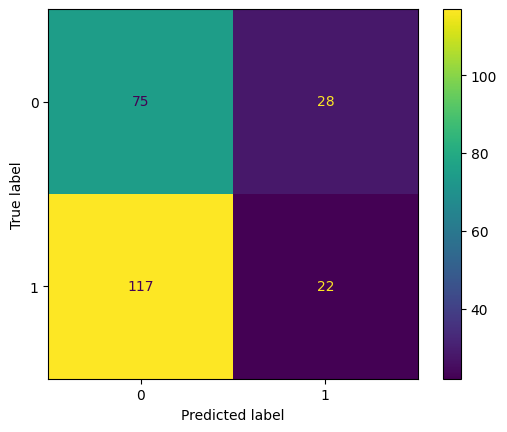

In [8]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    xgb_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [9]:
# feature importance
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
1,High,0.081627
9,MA_10,0.075656
5,Change,0.074428
3,Close,0.069934
6,Return,0.067475
0,Open,0.065762
2,Low,0.064683
13,MACD,0.060630
12,RSI,0.060423
11,Volatility,0.059493


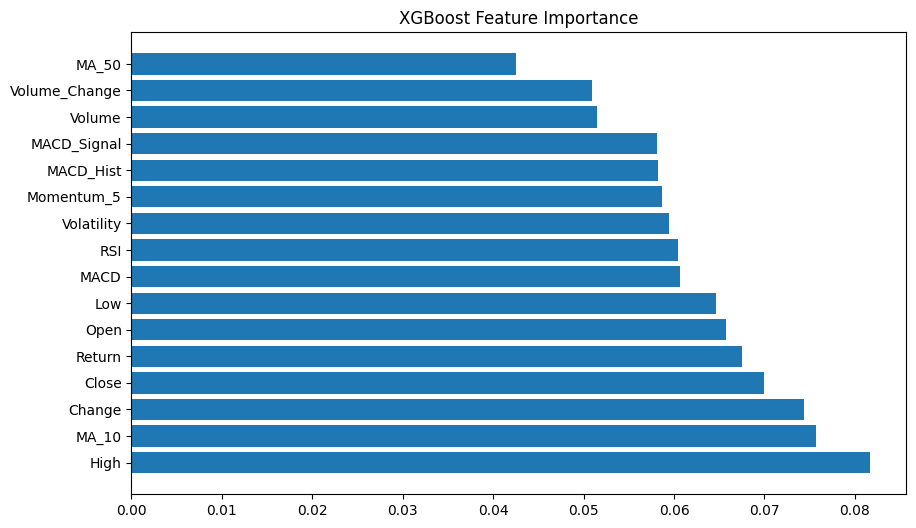

In [10]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title(
    "XGBoost Feature Importance"
)

plt.show()

# Observations

## Metrics

- **Accuracy:** 0.4008 (40.08%)
- **Precision:** 0.4400 (44.00%)
- **Recall:** 0.1583 (15.83%)

---

## Most Important Features

1. **High** (0.0816)
2. **MA_10** (0.0757)
3. **Change** (0.0744)
4. **Close** (0.0699)
5. **Return** (0.0675)

---

## Comparison with Logistic Regression & Random Forest

- **Did performance improve?**
  No, performance degraded across all metrics. Accuracy dropped to 0.4008 (compared to 0.4174 for Logistic Regression and 0.43 for Random Forest). Both Precision (0.4400) and Recall (0.1583) were also lower than the previous models.

- **Which features became important?**
  Price boundary levels (`High`, `Close`, `Open`, `Low`) and the shorter-term trend line (`MA_10`) became highly dominant, whereas Random Forest placed more emphasis on return momentum (`Return`, `Change`, `RSI`).

- **Did the model overfit?**
  Yes, heavily. XGBoost is highly prone to overfitting on noisy financial time-series data when hyperparameter tuning (like learning rate, max depth, and regularization) is not strictly constrained.

- **Does market behavior appear non-linear?**
  Yes, but the decline in test performance shows that applying complex tree-boosting algorithms to raw/standard features on noisy daily data leads to model failure. Non-linear relationships require stronger regularization or cleaner, more predictive feature engineering to be leveraged effectively.

In [11]:
# saving model
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    xgb_model,
    "../models/xgboost.pkl"
)

['../models/xgboost.pkl']